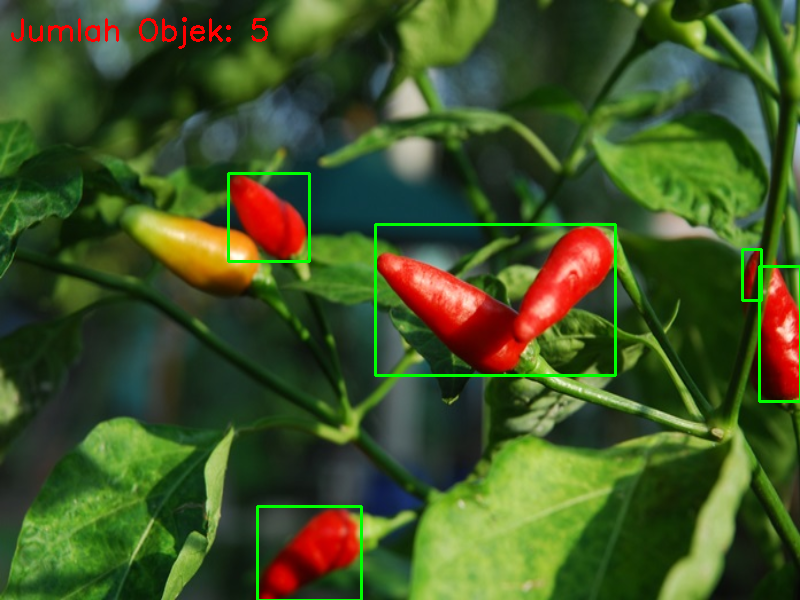

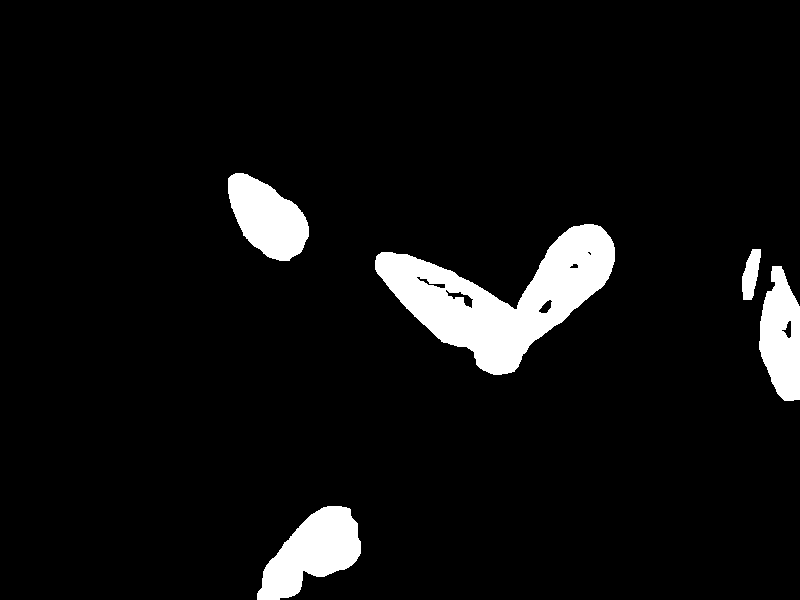

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# ===============================
# Load gambar dari file
# ===============================
image_path = "cabai.jpg"  # ganti dengan path gambar Anda
frame = cv2.imread(image_path)

if frame is None:
    print("Gambar tidak ditemukan!")
    exit()

# Resize opsional (agar tidak terlalu besar)
frame = cv2.resize(frame, (800, 600))

# ===============================
# Konversi ke HSV
# ===============================
hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

# ===============================
# Rentang warna (MERAH)
# ===============================
lower_red1 = np.array([0, 120, 70])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 120, 70])
upper_red2 = np.array([180, 255, 255])

mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
mask = mask1 + mask2

# ===============================
# Noise reduction
# ===============================
kernel = np.ones((5, 5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_DILATE, kernel)

# ===============================
# Deteksi kontur
# ===============================
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

object_count = 0

for cnt in contours:
    area = cv2.contourArea(cnt)

    # Filter noise
    if area > 500:
        object_count += 1

        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

# ===============================
# Tampilkan jumlah objek
# ===============================
cv2.putText(frame, f'Jumlah Objek: {object_count}', (10, 40),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

# ===============================
# Tampilkan hasil
# ===============================
cv2_imshow(frame)
cv2_imshow(mask)

cv2.waitKey(0)
cv2.destroyAllWindows()

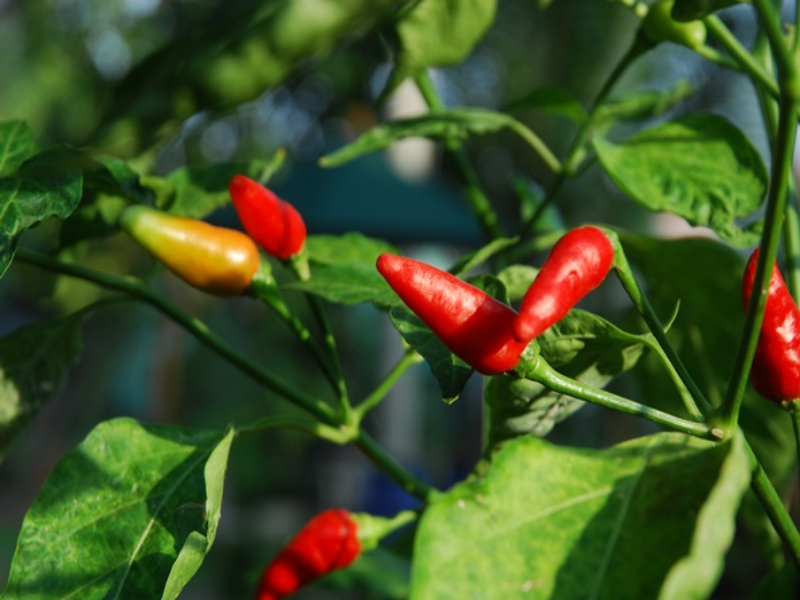

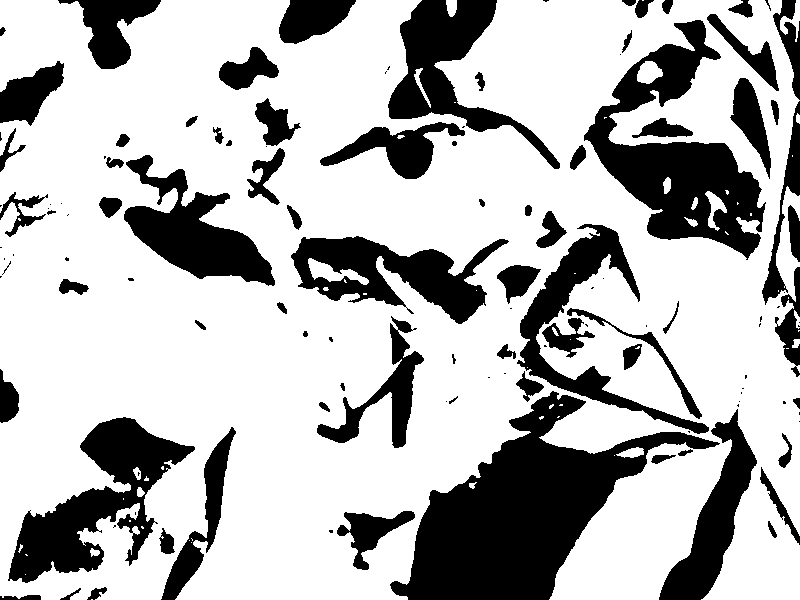

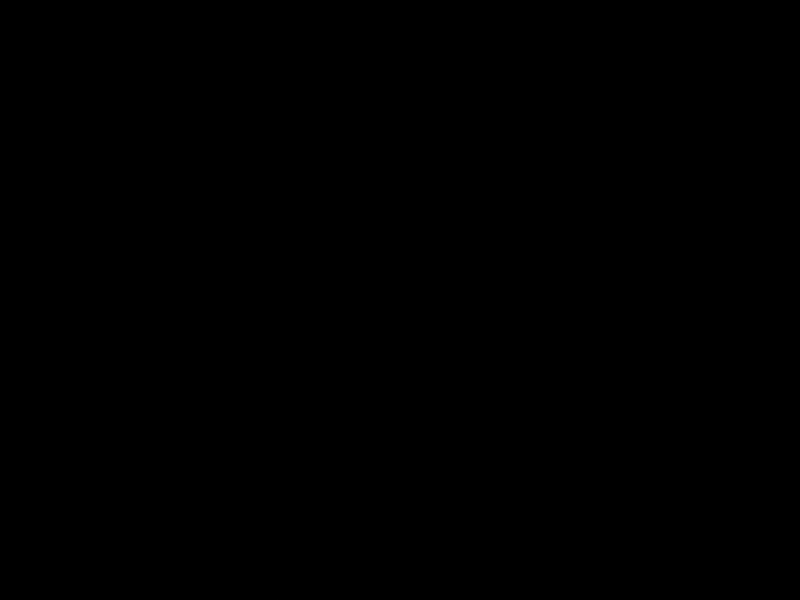

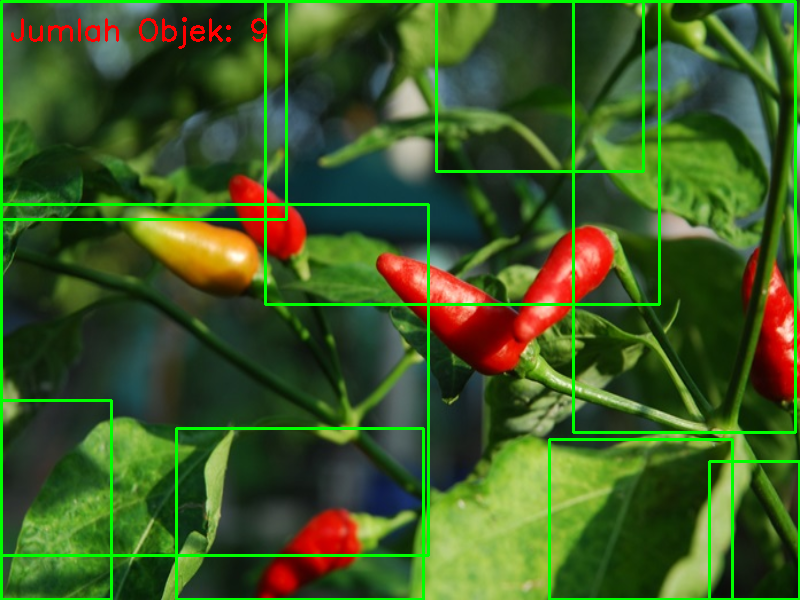

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load gambar
img = cv2.imread("cabai.jpg")
img = cv2.resize(img, (800, 600))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Threshold (binary)
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Noise removal
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Background area
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Distance transform
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

# Foreground area
_, sure_fg = cv2.threshold(dist_transform, 0.5*dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# Unknown region
unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labeling
_, markers = cv2.connectedComponents(sure_fg)

# Tambah 1 supaya background bukan 0
markers = markers + 1
markers[unknown == 255] = 0

# Watershed
markers = cv2.watershed(img, markers)

# Gambar hasil
output = img.copy()
object_count = 0

for label in np.unique(markers):
    if label <= 1:
        continue

    mask = np.zeros(gray.shape, dtype="uint8")
    mask[markers == label] = 255

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        if cv2.contourArea(cnt) > 500:
            object_count += 1
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(output, (x, y), (x+w, y+h), (0,255,0), 2)

# Tampilkan jumlah objek
cv2.putText(output, f'Jumlah Objek: {object_count}', (10,40),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2)

# Tampilkan hasil
cv2_imshow(img)
cv2_imshow(thresh)
cv2_imshow(dist_transform / dist_transform.max())
cv2_imshow(output)

cv2.waitKey(0)
cv2.destroyAllWindows()